In [35]:
from pathlib import Path
from torchvision import transforms
from PIL import Image

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
import librosa

In [36]:
def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")

In [4]:
def show_waveform(filepath: Path, label: str, figsize: tuple[int] = (10, 3), target_len: int = 4928):
    """Shows raw waveform of audio"""
    waveform, fs = torchaudio.load(filepath)
    waveform = waveform.squeeze(0)

    T = waveform.shape[0]
    if T > target_len:
        waveform = waveform[:target_len]
    else:
        waveform = F.pad(waveform, (0, target_len - T))

    plt.figure(figsize=figsize)
    plt.plot(waveform.numpy(), linewidth=0.8)
    plt.title(f"Raw waveform | label={label} | fs={fs}")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

In [20]:
def show_fft(filepath: Path, label: str, f_max: int = 0, figsize: tuple[int] = (10, 3)):
    """Shows FFT of the audio"""
    waveform, fs = torchaudio.load(filepath)
    signal = waveform.squeeze(0).numpy()
    
    fft = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), 1 / fs)

    mag = np.abs(fft)
    mag /= mag.max()  # normalize 0–1

    if f_max > 0:
        mask = freqs <= f_max
        freqs = freqs[mask]
        mag = mag[mask]

    plt.figure(figsize=figsize)
    plt.plot(freqs, mag)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (normalized)")
    plt.ylim(0, 1.0)
    plt.title(f"FFT: {label}")
    plt.tight_layout()
    plt.show()


In [37]:
def to_melspec(filepath: Path, n_fft: int = 1024, win_length: int = None, hop_length: int = 128, n_mels: int = 256):
    """Processes the audio to mel spectrogram""" 
    sample, fs = torchaudio.load(filepath)
    mel_spectrogram = T.MelSpectrogram(
        sample_rate=fs,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        center=True,
        pad_mode="reflect",
        power=2.0,
        norm="slaney",
        n_mels=n_mels,
        mel_scale="htk",
    )

    melspec = mel_spectrogram(sample)
    plot_spectrogram(melspec[0], filepath.name)

In [28]:
def show_melspec(filepath: Path, label: str, figsize: tuple[int] = (4, 4)):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])
    
    image = Image.open(filepath).convert("RGB")
    image = transform(image)
    image = torch.clamp(image, 0, 1)

    plt.figure(figsize=figsize)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"Spectrogram | label={label}")
    plt.tight_layout()
    plt.show()

In [9]:
rootdir = Path(os.getcwd()).parent
datadir = Path(rootdir, "data", "audio")
specdir = Path(datadir, "spec")
rawdir = Path(datadir, "recordings")

In [10]:
# Get all samples' path
spec_list = [x for x in specdir.glob("*.png")]
rec_list = [x for x in rawdir.glob("*.wav")]
print(len(spec_list), len(rec_list))

3000 3000


In [12]:
spec_list[0].__str__()

'/home/zheri/Projects/signal-processing-demo/data/audio/spec/5_lucas_22.png'

In [30]:
sample_idx = 1

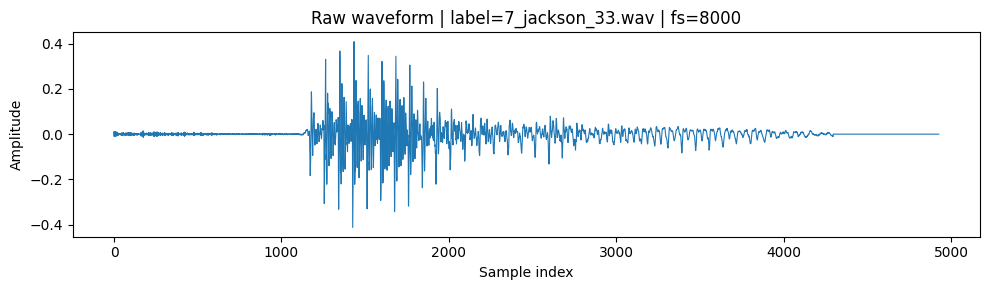

In [31]:
# Show raw recording example
show_waveform(rec_list[sample_idx], rec_list[sample_idx].name)

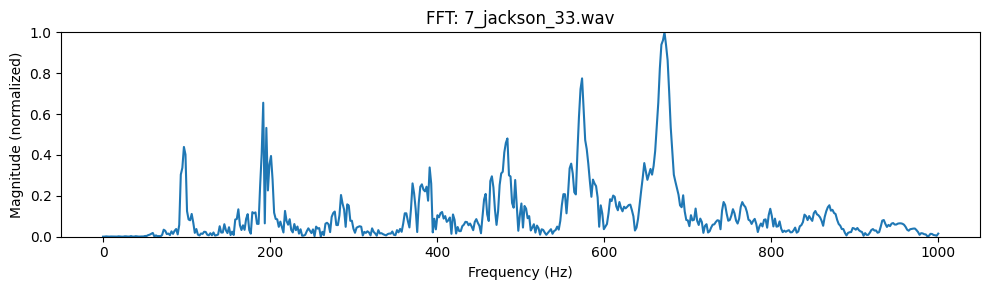

In [32]:
# Show fft of recording example
show_fft(rec_list[sample_idx], rec_list[sample_idx].name, f_max = 1000)

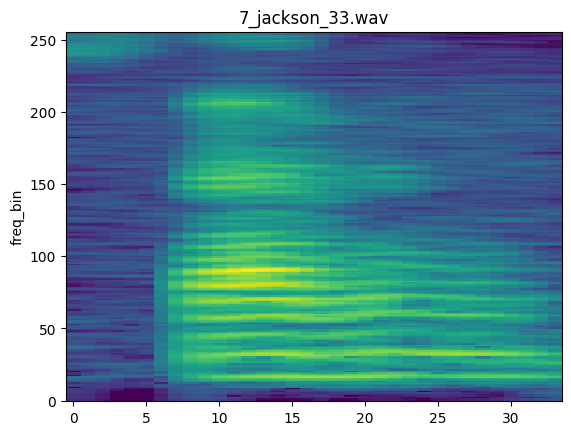

In [39]:
# Process raw sample to mel spec
to_melspec(rec_list[sample_idx])

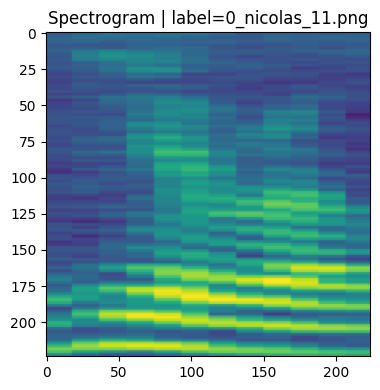

In [38]:
# Show mel spec example from dataset
show_melspec(spec_list[sample_idx], spec_list[sample_idx].name)